# Imports

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_val_predict,StratifiedGroupKFold,GridSearchCV

from sklearn.model_selection import GroupShuffleSplit


from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


# Workflow 

1. Import data: Train and Test data

2. GroupShuffleSplit

3. Model baselines trainining with default values

4. Gridsearch and Cross Validation: we look for the best hyperparameters

5. 5-fold StratifiedGroupKFold

6. choose best hyperparameters using mean CV F1

7. train best pipeline on all X_train_arr

8. evaluate once on X_test_arr

# Import data

Train data

In [2]:
x_train = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/train/X_train.txt',
    sep=r"\s+",  
    header=None)
print(x_train.shape)

y_train = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/train/y_train.txt',
    sep=r"\s+", 
    header=None,
    names=["activity"])

print(y_train.shape)


FileNotFoundError: [Errno 2] No such file or directory: 'human+activity+recognition+using+smartphones/UCI HAR Dataset/train/X_train.txt'

Test set

In [ ]:
x_test = pd.read_csv('human+activity+recognition+using+smartphones/UCI HAR Dataset/test/X_test.txt',
    sep=r"\s+", 
    header=None)

print(x_test.shape)


y_test = pd.read_csv('/Users/agustindei/Documents/Master_unipa/verifica_ml_dl/human+activity+recognition+using+smartphones/UCI HAR Dataset/test/y_test.txt',
    sep=r"\s+",  
    header=None,
    names=["activity"])

print(y_test.shape)

(2947, 561)
(2947, 1)


Soggetti dell'esperimentazione

In [ ]:
subject_train = pd.read_csv(
    'human+activity+recognition+using+smartphones/UCI HAR Dataset/train/subject_train.txt',
    sep=r"\s+", 
    header=None,
    names=["subject"]

    )

subject_train_arr = subject_train.values.ravel()

In [ ]:
X_train_arr = x_train.values
y_train_arr = y_train.values.ravel()  # vettore riga

X_test_arr = x_test.values
y_test_arr = y_test.values.ravel() # vettore riga 

## Split train set: train - val 

Usiamo GroupShuffleSplit per evitare che un soggetto si ritrovi nel train e nel val sets.



In [ ]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, val_idx = next(
    gss.split(
        X_train_arr,
        y_train_arr,
        groups=subject_train_arr
    )
)

x_tr = X_train_arr[train_idx]
x_val = X_train_arr[val_idx]

y_tr = y_train_arr[train_idx]
y_val = y_train_arr[val_idx]

Shapes train e val sets

In [ ]:
print("X_train shape:", x_tr.shape) 
print("y_train shape:", y_tr.shape) 
print("X_val shape:", x_val.shape)   
print("y_val shape:", y_val.shape)   

print("X_test shape:", X_test_arr.shape)   
print("y_test shape:", y_test_arr.shape)  


X_train shape: (5551, 561)
y_train shape: (5551,)
X_val shape: (1801, 561)
y_val shape: (1801,)
X_test shape: (2947, 561)
y_test shape: (2947,)


Sanity check del protocollo cross-subject 

In [ ]:
train_subjects = np.unique(subject_train_arr[train_idx])
val_subjects = np.unique(subject_train_arr[val_idx])

print("Soggetti train set :", train_subjects)
print("Soggetti validation set subjects:", val_subjects)

print("Soggetti in entrambi sets:",
    np.intersect1d(train_subjects, val_subjects)
)

Soggetti train set : [ 5  6  7  8 11 14 16 17 19 21 22 23 26 28 29 30]
Soggetti validation set subjects: [ 1  3 15 25 27]
Soggetti in entrambi sets: []


## Tested Pipelines (pre-processing and models)

| Experiment           | Input                     | Reduction | Why                                                 |
| -------------------- | ------------------------- | --------- | --------------------------------------------------- |
| Baseline             | 561 features              | None      |
| PCA                  | 102 features              | PCA 95%   | Remove linear redundancy                            |
| StandardScaler + PCA | 65 standardized features | PCA 95%   | Remove influence of unequal feature variance        |
| LDA                  | 5 features + 6 labels     | Max 5 LDs | Supervised reduction optimized for class separation |



| Tested Model Pipelines without cross-validation |
| ---------------------------------------------- 
| SVM (linear kernel)                          | 
| SVM (kernel rbf)                             | 
| SVM (polynomial kernel)                      | 
| StandardScaler + Linear SVM                  |
| StandardScaler + RBF SVM                     |
| StandardScaler + Polynomial SVM              |
| PCA + Linear SVM                             |
| LDA + Linear SVM                             |


| Tested Model Pipelines with cross-validation   |
| ---------------------------------------------- 
| SVM (linear kernel)                            |
| SVM (kernel rbf)                               |
| SVM (polynomial kernel)                        |
| StandardScaler + Linear SVM                    |
| StandardScaler + RBF SVM                       |
| StandardScaler + Polynomial SVM                |
| LDA + LINEAR SVM                               |
| LDA + RBF SVM                                  |
| LDA + Polynomial SVM                           |

# 2. Training 

##  Baseline models (senza dimensionality reduction)

Baseline models

- Linear SVM
- RBF SVM
- Polynomial SVM

- StandardScaler + Linear SVM
- StandardScaler + RBF SVM
- StandardScaler + Polynomial SVM

In [ ]:
baseline_models = {
    "Linear SVM": make_pipeline(
        SVC(kernel="linear")
    ),

    "PCA + Linear SVM": make_pipeline(
        PCA(n_components=0.95),
        SVC(kernel="linear")
    ),

    "LDA + Linear SVM": make_pipeline(
        LinearDiscriminantAnalysis(),
        SVC(kernel="linear")
    ),
    
    "RBF SVM": make_pipeline(
        SVC(kernel="rbf")
    ),

    "Polynomial SVM": make_pipeline(
        SVC(kernel="poly")
    ),

    "StandardScaler + Linear SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="linear")
    ),

    "StandardScaler + RBF SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf")
    ),

    "StandardScaler + Polynomial SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="poly")
    )

}

In [ ]:
results = []

for name, model in baseline_models.items():

    # Train 
    model.fit(x_tr, y_tr)

    # Predictions
    y_train_pred = model.predict(x_tr)
    y_val_pred = model.predict(x_val)
   

    # Classification reports 
    train_report = classification_report(
        y_tr,
        y_train_pred,
        output_dict=True
    )

    val_report = classification_report(
        y_val,
        y_val_pred,
        output_dict=True
    )

    results.append({
        "Model": name,

        "C": f'{model.named_steps["svc"].C} (default value)',
        "Train Accuracy": train_report["accuracy"],
        "Val Accuracy": val_report["accuracy"],

        "Train F1": train_report["macro avg"]["f1-score"],
        "Val F1": val_report["macro avg"]["f1-score"],
  
    })


results_df = pd.DataFrame(results)

results_df.round(4)

,Model,C,Train Accuracy,Val Accuracy,Train F1,Val F1
0,Linear SVM,1.0 (default value),0.9944,0.9528,0.9949,0.9474
1,PCA + Linear SVM,1.0 (default value),0.9773,0.9423,0.9794,0.9347
2,LDA + Linear SVM,1.0 (default value),0.9877,0.9595,0.9889,0.9550
3,RBF SVM,1.0 (default value),0.9759,0.9622,0.9780,0.9572
4,Polynomial SVM,1.0 (default value),0.9910,0.9628,0.9918,0.9581
5,StandardScaler + Linear SVM,1.0 (default value),0.9969,0.9456,0.9972,0.9403
6,StandardScaler + RBF SVM,1.0 (default value),0.9868,0.9478,0.9881,0.9425
7,StandardScaler + Polynomial SVM,1.0 (default value),0.9802,0.9378,0.9818,0.9298


## Gridsearch e cross validation 

- Ricerca dei migliori iperparametri

In [ ]:
linear_models = {
    "Linear SVM": make_pipeline(
        SVC(kernel="linear")
    ),

    "PCA + Linear SVM": make_pipeline(
        PCA(n_components=0.95),
        SVC(kernel="linear")
    ),

    "LDA + Linear SVM": make_pipeline(
        LinearDiscriminantAnalysis(),
        SVC(kernel="linear")
    ),
}


param_grid = {
    "svc__C": [0.01, 0.1, 1, 10, 100]
}

kernel_models = {

    "RBF SVM": {
        "pipeline": make_pipeline(
            SVC(kernel="rbf")
        ),
        "params": {
            "svc__C": [0.1, 1, 10, 100],
            "svc__gamma": ["scale", 0.001, 0.01, 0.1, 1]
        }
    },

    "Polynomial SVM": {
        "pipeline": make_pipeline(
            SVC(kernel="poly")
        ),
        "params": {
            "svc__C": [0.1, 1, 10],
            "svc__gamma": ["scale", 0.01, 0.1],
            "svc__degree": [2, 3]
        }
    }
}

In [ ]:

# cross validation strategy
# by group for avoiding data leakage and streatified
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)  


linear_results = {}


for name, model in linear_models.items():

    grid = GridSearchCV(
        model,
        param_grid=param_grid,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True    # refit dei best parameters in TUTTO in dataset train --> 
        #grid.best_estimator_ è il modello finale addestrato su tutti i campioni di training
    )

    grid.fit(
        X_train_arr,   # usiamo l'intero training set che sera splitato in 5 folds in training e validation sets
        y_train_arr,
        groups=subject_train_arr
    )

    best_idx = grid.best_index_


    linear_results[name] = {
        "model": grid.best_estimator_,
        "best_params": grid.best_params_,
        "best_cv_f1": grid.best_score_,
        "cv_f1_std": grid.cv_results_["std_test_score"][best_idx]
        # l'attributo cv_results_ consente di recuperare anche la deviazione standard 
    }




In [ ]:
kernel_results = {}

for name, config in kernel_models.items():

    grid = GridSearchCV(
        config["pipeline"],
        config["params"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,  
        refit=True
    )

    grid.fit(
        X_train_arr,
        y_train_arr,
        groups=subject_train_arr
    )

    best_idx = grid.best_index_

    kernel_results[name] = {
        "model": grid.best_estimator_,
        "best_params": grid.best_params_,

        "best_cv_f1": grid.cv_results_["mean_test_score"][best_idx],
        "cv_f1_std": grid.cv_results_["std_test_score"][best_idx]
    }


In [ ]:
results = []

for name, info in linear_results.items():

    # Best estimator --> best model
    model = info["model"]

    # Training predictions
    y_train_pred = model.predict(X_train_arr)

    train_report = classification_report(
        y_train_arr,
        y_train_pred,
        output_dict=True
    )

    results.append({
        "Model": f"{name} + cross validation + grid search",

        "Best Parameters": info["best_params"],

        "CV Macro F1 Mean": info["best_cv_f1"],
        "CV Macro F1 Std": info["cv_f1_std"],

        "Train Accuracy": train_report["accuracy"],
        "Train F1": train_report["macro avg"]["f1-score"]
    })


best_linear_df = pd.DataFrame(results)

best_linear_df.round(4)

,Model,Best Parameters,CV Macro F1 Mean,CV Macro F1 Std,Train Accuracy,Train F1
0,Linear SVM + cross validation + grid search,{'svc__C': 1},0.9307,0.0337,0.9939,0.9944
1,PCA + Linear SVM + cross validation + grid search,{'svc__C': 0.1},0.9094,0.0378,0.9743,0.9759
2,LDA + Linear SVM + cross validation + grid search,{'svc__C': 0.01},0.9531,0.0201,0.9867,0.9877


In [ ]:
for name, info in kernel_results.items():


    model = info["model"]
    print(model)
    print(name)
    print(info["best_params"])

Pipeline(steps=[('svc', SVC(C=10, gamma=0.01))])
RBF SVM
{'svc__C': 10, 'svc__gamma': 0.01}
Pipeline(steps=[('svc', SVC(C=10, kernel='poly'))])
Polynomial SVM
{'svc__C': 10, 'svc__degree': 3, 'svc__gamma': 'scale'}


In [ ]:
kernel_evaluation_results = []

for name, info in kernel_results.items():

    model = info["model"]

    y_train_pred = model.predict(X_train_arr) # runs the pipeline

    train_report = classification_report(
        y_train_arr,
        y_train_pred,
        output_dict=True
    )


    kernel_evaluation_results.append({
        "Model": f'{name} + cross validation + grid search',
        "Best Parameters": info["best_params"],

        "CV Macro F1 Mean": info["best_cv_f1"],
        "CV Macro F1 Std": info["cv_f1_std"],

        "Train Accuracy": train_report["accuracy"],
        "Train F1": train_report["macro avg"]["f1-score"],
    })


kernel_results_df = pd.DataFrame(kernel_evaluation_results)

In [ ]:
grid_results = pd.concat([best_linear_df, kernel_results_df], ignore_index=True)
grid_results


,Model,Best Parameters,CV Macro F1 Mean,CV Macro F1 Std,Train Accuracy,Train F1
0,Linear SVM + cross validation + grid search,{'svc__C': 1},0.930723,0.033736,0.993879,0.994355
1,PCA + Linear SVM + cross validation + grid search,{'svc__C': 0.1},0.909428,0.037803,0.974293,0.975872
2,LDA + Linear SVM + cross validation + grid search,{'svc__C': 0.01},0.953068,0.020051,0.986670,0.987691
3,RBF SVM + cross validation + grid search,"{'svc__C': 10, 'svc__gamma': 0.01}",0.934728,0.024314,0.995919,0.996237
4,Polynomial SVM + cross validation + grid search,"{'svc__C': 10, 'svc__degree': 3, 'svc__gamma':...",0.935801,0.024557,0.997688,0.997868


### Non linear kernels


In [ ]:
lda_grid_nonlinear = {


    "LDA + RBF SVM": {
        "pipeline": make_pipeline(
            LinearDiscriminantAnalysis(),
            SVC(kernel="rbf")
        ),
        "params": {
            "svc__C": [0.1, 1, 10, 100],
            "svc__gamma": ["scale", 0.001, 0.01, 0.1, 1]
        }
    },

    "LDA + Polynomial SVM": {
        "pipeline": make_pipeline(
            LinearDiscriminantAnalysis(),
            SVC(kernel="poly")
        ),
        "params": {
            "svc__C": [0.1, 1, 10],
            "svc__gamma": ["scale", 0.01, 0.1],
            "svc__degree": [2, 3]
        }
    }
}

In [ ]:
lda_results = {}

for name, config in lda_grid_nonlinear.items():

    grid = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["params"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        refit=True
    )

    grid.fit(
        X_train_arr,
        y_train_arr,
        groups=subject_train_arr
    )

    best_idx = grid.best_index_

    lda_results[name] = {
        "model": grid.best_estimator_,
        "best_params": grid.best_params_,
        "best_cv_f1": grid.cv_results_["mean_test_score"][best_idx],
        "cv_f1_std": grid.cv_results_["std_test_score"][best_idx]
    }

In [ ]:
results_lda = []

for name, info in lda_results.items():

    # Extract the fitted best estimator
    model = info["model"]

    y_train_pred = model.predict(X_train_arr)

    train_report = classification_report(
        y_train_arr,
        y_train_pred,
        output_dict=True
    )

    results_lda.append({
        "Model": f"{name} + cross validation + grid search",

        "Best Parameters": info["best_params"],

        "CV Macro F1 Mean": info["best_cv_f1"],
        "CV Macro F1 Std": info["cv_f1_std"],

        "Train Accuracy": train_report["accuracy"],
        "Train F1": train_report["macro avg"]["f1-score"]
    })


results_lda_df = pd.DataFrame(results_lda)

results_lda_df.round(4)

,Model,Best Parameters,CV Macro F1 Mean,CV Macro F1 Std,Train Accuracy,Train F1
0,LDA + RBF SVM + cross validation + grid search,"{'svc__C': 1, 'svc__gamma': 0.001}",0.9534,0.0200,0.9865,0.9876
1,LDA + Polynomial SVM + cross validation + grid...,"{'svc__C': 1, 'svc__degree': 3, 'svc__gamma': ...",0.9511,0.0198,0.9867,0.9877


In [ ]:
grid_results = pd.concat([grid_results, results_lda_df], ignore_index=True)
grid_results.sort_values('CV Macro F1 Mean', ascending=False)


,Model,Best Parameters,CV Macro F1 Mean,CV Macro F1 Std,Train Accuracy,Train F1
5,LDA + RBF SVM + cross validation + grid search,"{'svc__C': 1, 'svc__gamma': 0.001}",0.953449,0.019999,0.986534,0.987587
2,LDA + Linear SVM + cross validation + grid search,{'svc__C': 0.01},0.953068,0.020051,0.986670,0.987691
6,LDA + Polynomial SVM + cross validation + grid...,"{'svc__C': 1, 'svc__degree': 3, 'svc__gamma': ...",0.951128,0.019753,0.986670,0.987709
4,Polynomial SVM + cross validation + grid search,"{'svc__C': 10, 'svc__degree': 3, 'svc__gamma':...",0.935801,0.024557,0.997688,0.997868
3,RBF SVM + cross validation + grid search,"{'svc__C': 10, 'svc__gamma': 0.01}",0.934728,0.024314,0.995919,0.996237
0,Linear SVM + cross validation + grid search,{'svc__C': 1},0.930723,0.033736,0.993879,0.994355
1,PCA + Linear SVM + cross validation + grid search,{'svc__C': 0.1},0.909428,0.037803,0.974293,0.975872


In [ ]:
results_df.sort_values('Val F1', ascending=False)

,Model,C,Train Accuracy,Val Accuracy,Train F1,Val F1
4,Polynomial SVM,1.0 (default value),0.990993,0.962798,0.991811,0.958147
3,RBF SVM,1.0 (default value),0.975860,0.962243,0.978018,0.957217
2,LDA + Linear SVM,1.0 (default value),0.987750,0.959467,0.988911,0.955045
0,Linear SVM,1.0 (default value),0.994415,0.952804,0.994946,0.947437
6,StandardScaler + RBF SVM,1.0 (default value),0.986849,0.947807,0.988093,0.942458
5,StandardScaler + Linear SVM,1.0 (default value),0.996937,0.945586,0.997228,0.940283
1,PCA + Linear SVM,1.0 (default value),0.977301,0.942254,0.979439,0.934726
7,StandardScaler + Polynomial SVM,1.0 (default value),0.980184,0.937812,0.981837,0.929831


## Best Baseline Model vs Best Tuned Model via GridSearch

Valutiamo la performance della configurazione del migliore modello baseline con cross-validation per poter fare un confronto finale.

Selezioniamo il modello SVM LDA+RBF, che, a seguito della ricerca degli iperparametri su un dataset a dimensionalità ridotta, ottiene il miglior F1-score medio, pari a 0.953449, e lo confrontiamo con il miglior modello baseline.

Tra i modelli baseline, il modello Polynomial SVM, utilizzato con i valori di default degli iperparametri e senza applicare tecniche di riduzione della dimensionalità nella fase di pre-processing dei dati, raggiunge un F1-score di 0.958147 sul validation set, ottenuto mediante GroupShuffleSplit. Tuttavia, per effettuare un confronto con il miglior modello ottimizzato, è necessario valutare anche il modello baseline mediante cross-validation.

In [ ]:
from sklearn.model_selection import cross_val_score

default_rbf = make_pipeline(
    SVC(kernel="poly")
)

scores = cross_val_score(
    default_rbf,
    X_train_arr,
    y_train_arr,
    groups=subject_train_arr,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print(
    f"Default Polynomial CV macro F1: "
    f"{scores.mean():.4f} ± {scores.std():.4f}")

Default Polynomial CV macro F1: 0.9353 ± 0.0260


In [ ]:
default_rbf = make_pipeline(
    LinearDiscriminantAnalysis(),
    SVC(kernel="poly"),
    
)

scores = cross_val_score(
    default_rbf,
    X_train_arr,
    y_train_arr,
    groups=subject_train_arr,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print(
    f"LDA + Default Polynomial CV macro F1: "
    f"{scores.mean():.4f} ± {scores.std():.4f}")

LDA + Default Polynomial CV macro F1: 0.9482 ± 0.0214


Sebbene il risultato ottenuto attraverso GroupShuffleSplit sia leggermente superiore a quello di Polynomial SVM tramite GridSearch e cross-validation, se addestrato tramite cross-validation con i valori default dei paramentri le prestazioni diminuiscono: CV Macro F1 = 0.9353 con una deviazione standard di ± 0.0260

Pertanto, il modello SVM con kernel RBF ottimizzato e addestrato su il dataset a dimensionalità ridotta mediante LDA presenta prestazioni leggermente superiori rispetto al miglior modello baseline.

### Evaluation of the selected model once on test


Classification Report:
              precision    recall  f1-score   support

           1     0.9820    0.9879    0.9849       496
           2     0.9686    0.9830    0.9758       471
           3     1.0000    0.9786    0.9892       420
           4     0.9520    0.8880    0.9189       491
           5     0.9043    0.9586    0.9307       532
           6     1.0000    1.0000    1.0000       537

    accuracy                         0.9661      2947
   macro avg     0.9678    0.9660    0.9666      2947
weighted avg     0.9667    0.9661    0.9660      2947



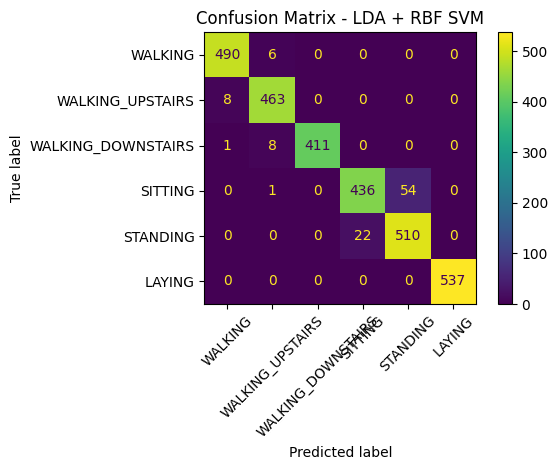

In [ ]:
# Modello selezionato 
final_model_name = "LDA + RBF SVM"

final_model = lda_results[final_model_name]["model"]

# Final predictions
y_test_pred = final_model.predict(X_test_arr)

print("\nClassification Report:")
print(classification_report(
        y_test_arr,
        y_test_pred,
        digits=4
    )
)


# Matrice di confusione
cm = confusion_matrix(
    y_test_arr,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "WALKING",
        "WALKING_UPSTAIRS",
        "WALKING_DOWNSTAIRS",
        "SITTING",
        "STANDING",
        "LAYING"
    ]
)

disp.plot(xticks_rotation=45)

plt.title(f"Confusion Matrix - {final_model_name}")
plt.tight_layout()
plt.show()